In [1]:
import pandas as pd
import matplotlib.pyplot as plt

members_df = pd.read_excel("gym_data.xlsx", sheet_name="Members")

print(members_df.head())
print("Data loaded ✅")

FileNotFoundError: [Errno 2] No such file or directory: 'gym_data.xlsx'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

members_df = pd.read_excel(r"C:\Users\HP\gym_project\gym_data.xlsx", sheet_name="Members")

print(members_df.head())
print("Data loaded ✅")

  member_id        name  join_date membership_type  monthly_fee    status
0      M001  Ravi Kumar 2023-05-19           Basic          800  Inactive
1      M002     Priya S 2023-04-15         Student          500    Active
2      M003    Anjali R 2023-03-29         Premium         1500    Active
3      M004    Suresh M 2023-11-24         Premium         1500    Active
4      M005     Deepa K 2023-12-13           Basic          800  Inactive
Data loaded ✅


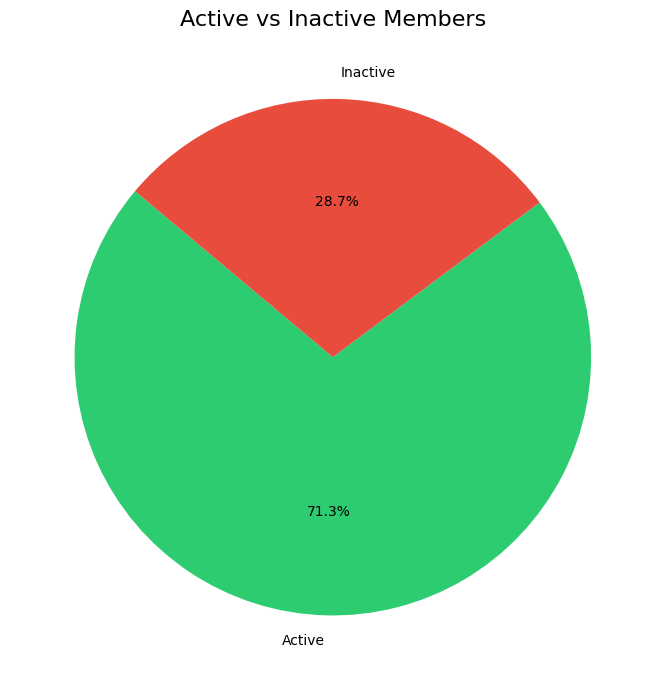

In [2]:
status_counts = members_df["status"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%", 
        colors=["#2ecc71", "#e74c3c"], startangle=140)
plt.title("Active vs Inactive Members", fontsize=16)
plt.tight_layout()
plt.show()

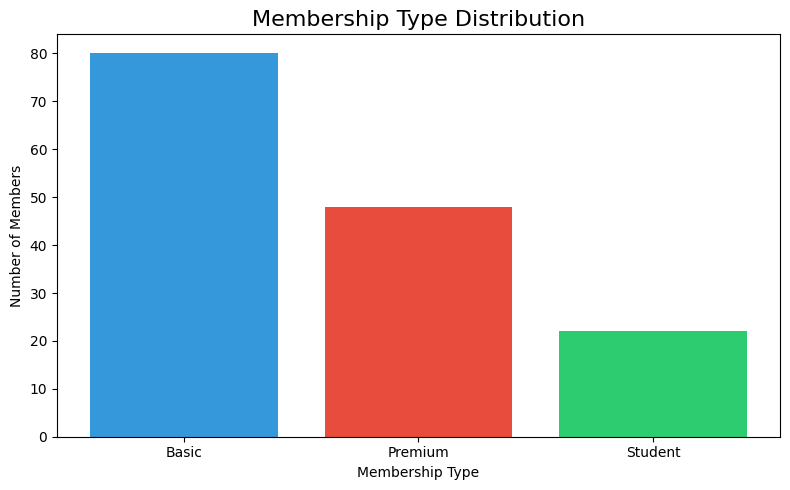

In [3]:
type_counts = members_df["membership_type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("Membership Type Distribution", fontsize=16)
plt.xlabel("Membership Type")
plt.ylabel("Number of Members")
plt.tight_layout()
plt.show()

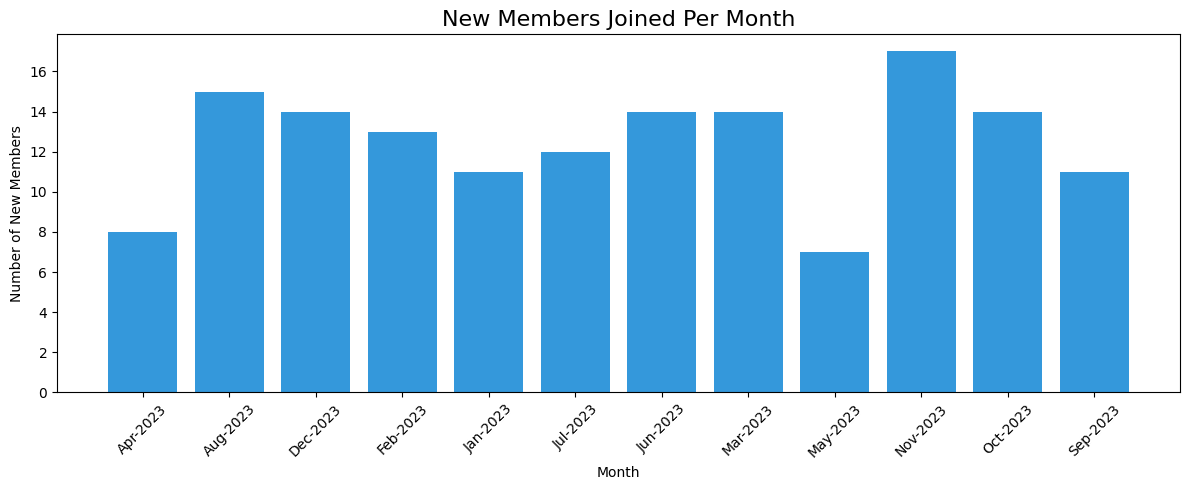

In [4]:
members_df["join_date"] = pd.to_datetime(members_df["join_date"])
members_df["join_month"] = members_df["join_date"].dt.strftime("%b-%Y")

monthly_joins = members_df.groupby("join_month")["member_id"].count()

plt.figure(figsize=(12, 5))
plt.bar(monthly_joins.index, monthly_joins.values, color="#3498db")
plt.title("New Members Joined Per Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of New Members")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

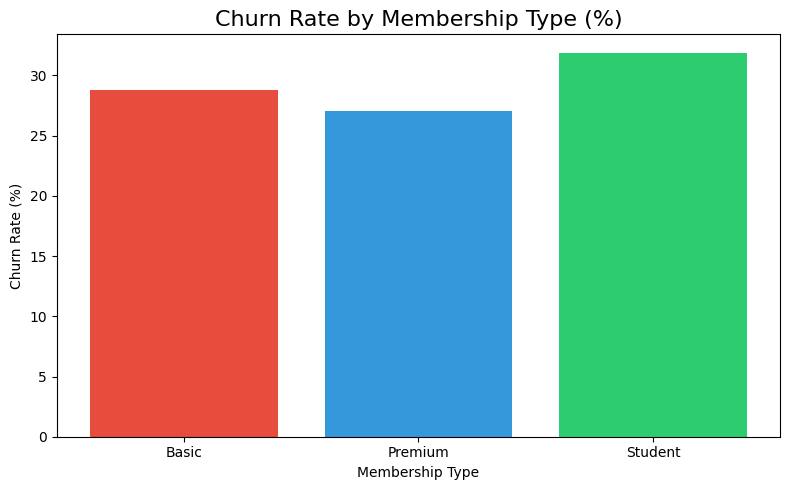

In [5]:
churn = members_df.groupby("membership_type")["status"].apply(
    lambda x: (x == "Inactive").sum() / len(x) * 100
)

plt.figure(figsize=(8, 5))
plt.bar(churn.index, churn.values, color=["#e74c3c", "#3498db", "#2ecc71"])
plt.title("Churn Rate by Membership Type (%)", fontsize=16)
plt.xlabel("Membership Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()